## Parameter estimation - Bayesian inference
**Source:** Grinsztajn, L., Semenova, E., Margossian, C. C. & Riou, J. Bayesian workflow for disease transmission modeling in Stan. Stat Med 40, 6209–6234 (2021).

**Source Git:** https://github.com/charlesm93/disease_transmission_workflow

**Motivation:** Infectious disease surveillance data is sparse, and we have mechanistic as well as prior domain knowledge about disease spread. And there is natural hierarchy in infectious disease spread data collection process, for example, going from a region to state, then from state to country and then globally. So, if data is less or unavailable, it is beneficial to use the data for neighbouring regions or states to infer the disease spread dynamics. 

**Illustration:** A compartmental model, Susceptible-Infected-Recovered (SIR) model for an outbreak of influenza A (H1N1) in 1978 at a British Boarding School.

**Data source:** R package outbreaks or R Epidemics Consortium. I am working in Python, so downaloaded the data as .RData file from https://github.com/reconverse/outbreaks/tree/master/data



In [175]:
import pyreadr ## for reading .RData files
import pandas as pd ## for data manipulation
import matplotlib.pyplot as plt ## for plotting

## for using stan in python
import stan 
import nest_asyncio
nest_asyncio.apply()

from matplotlib.ticker import FormatStrFormatter
import matplotlib as mpl
import seaborn as sns

mpl.rcParams["mathtext.fontset"] = "stix" ## for using STIX fonts in mathtext
mpl.rcParams["font.family"] = "STIXGeneral" ## for using STIX fonts in mathtext
## plotting parameters for matplotlib and seaborn
mpl.rcParams.update({
     "figure.dpi": 300,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,

    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    "axes.linewidth": 1.5,
    "lines.linewidth": 2.5,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.major.size": 6,
    "ytick.major.size": 6,

    "legend.frameon": False
})

sns.set_style("darkgrid", {"axes.facecolor": ".95"}) ## for using seaborn style for plots


In [165]:
data_dict = pyreadr.read_r("influenza_england_1978_school.RData")
df = data_dict['influenza_england_1978_school']

In [166]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df['month_day'] = df['date'].dt.strftime('%m-%d')

Text(0.5, 1.0, 'Influenza in England 1978 School Outbreak')

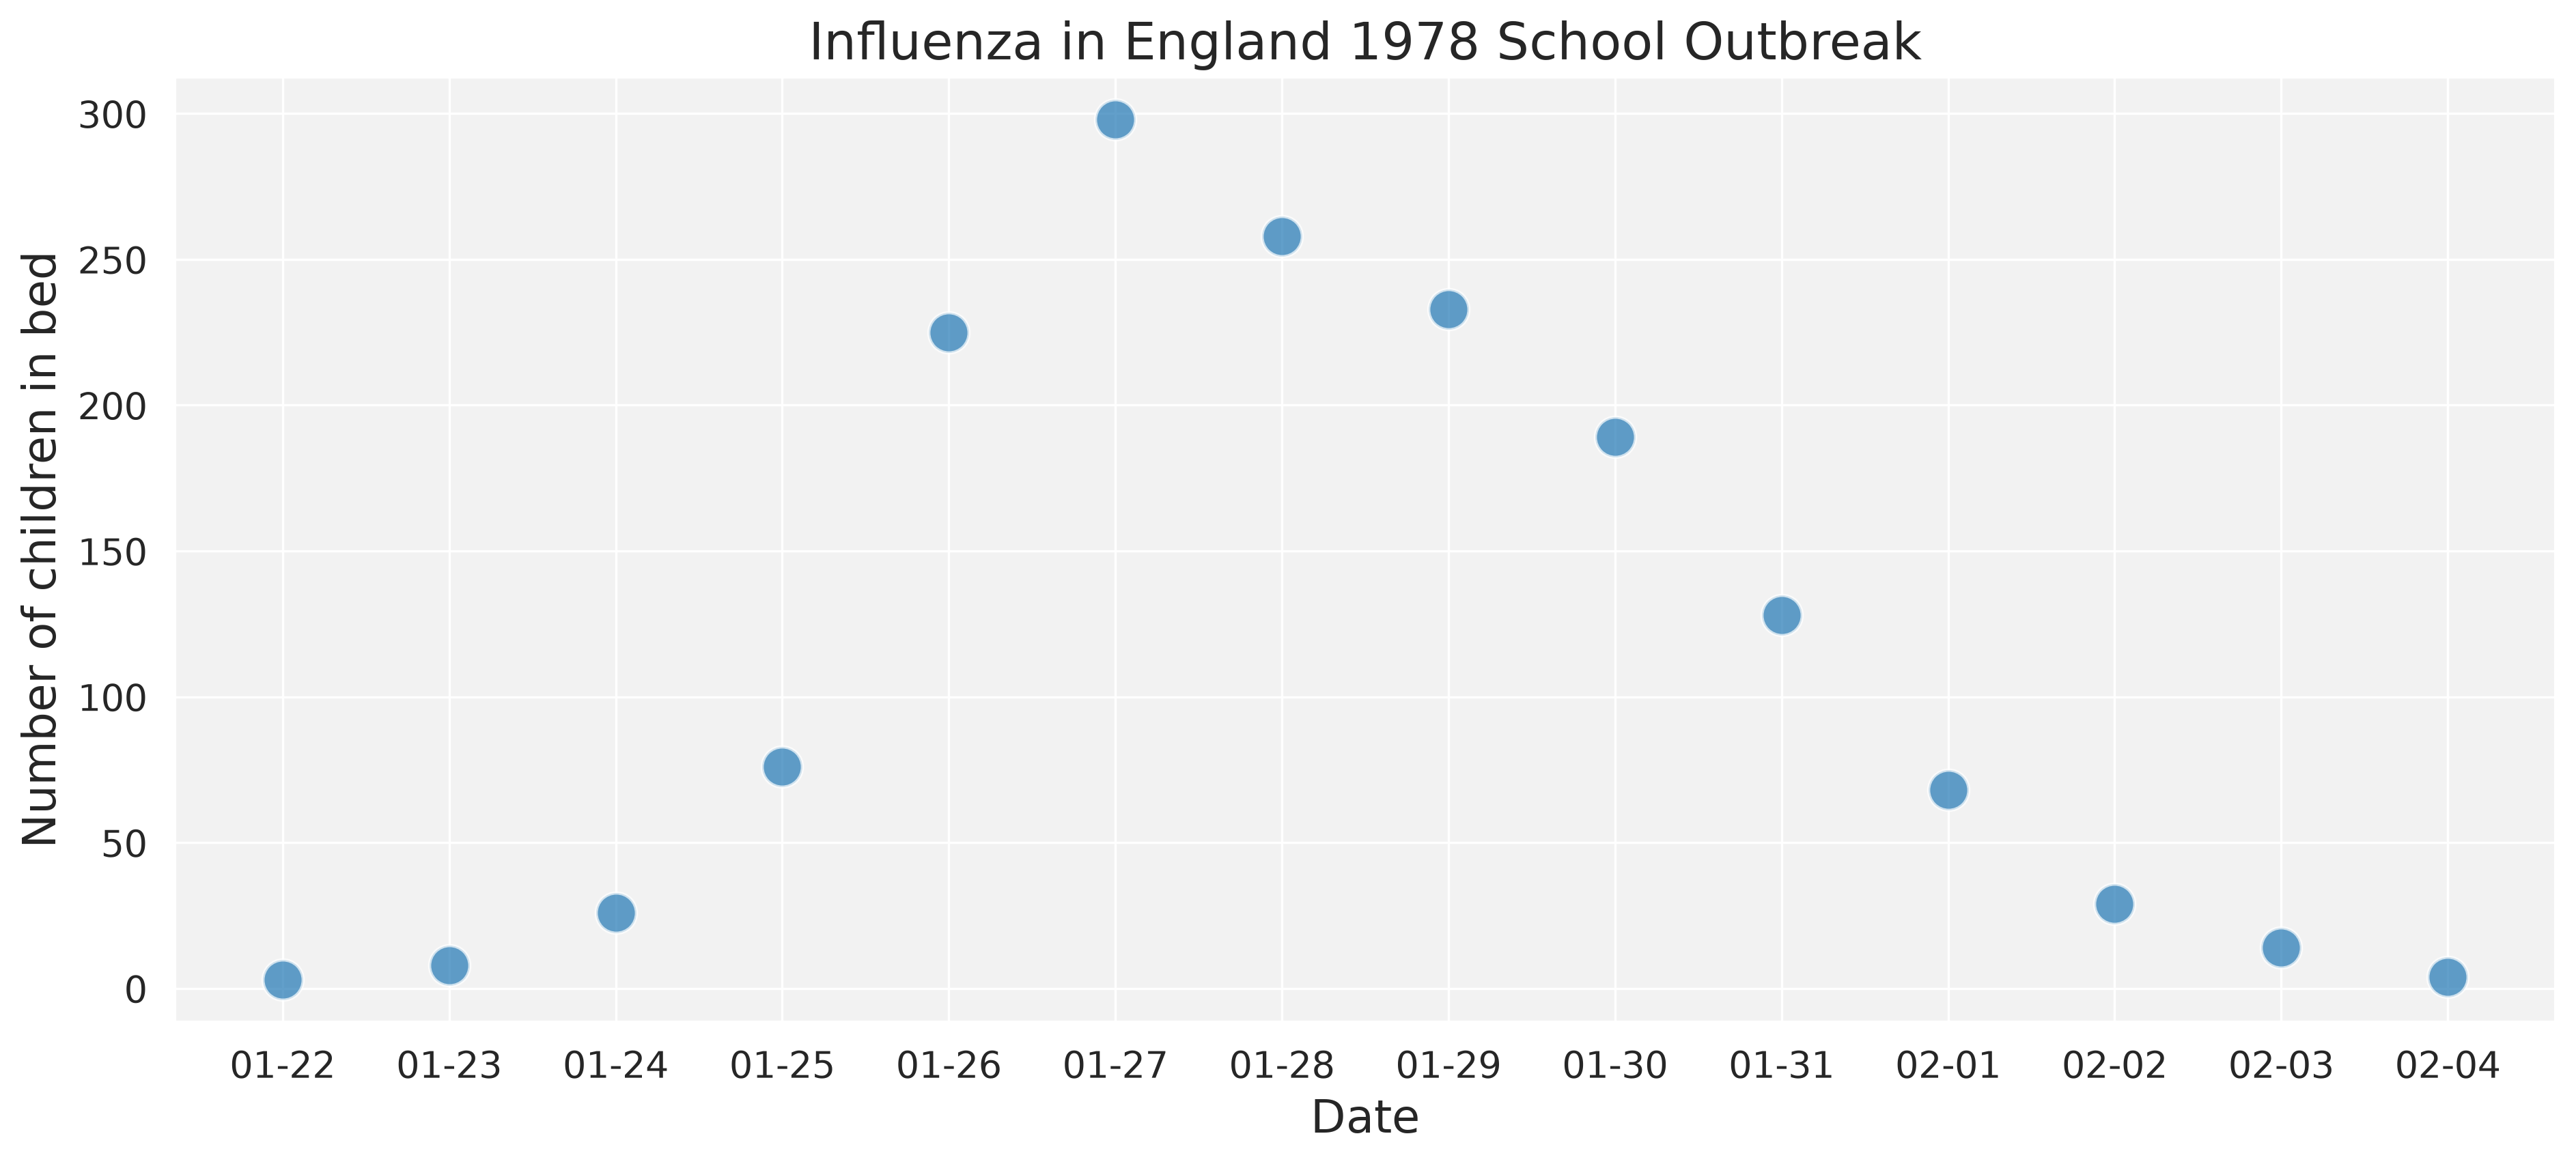

In [178]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data = df, x='month_day', y='in_bed',s=200, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Number of children in bed")
plt.title("Influenza in England 1978 School Outbreak")

**Observed data:** The number of children in bed which is the number of infected ($I(t)$).

**Latent variables:** The number of susceptibles ($S(t)$), and number of recovered ($R(t)$).

**Model parameters:** Transmission rate ($\beta$), recovery rate ($\gamma$), and over-dispersion parameter ($\phi$). Don't what is the over-dispersion parameter and why we need it?

## Bayesian set up

**Sampling distribution:** Probability of observing $I(t)$ given $\beta,\gamma,$ and $\phi$, denoted by $P(y|\theta)$, where $\theta$ represents the list of three parameters. We are modelling the count data, so we chose Negative Binomial Distribution. Are there others? Why do we choose Negative Binomial?
\begin{align}
P(y|\theta) &= \text{Negative-Binomial}(y|I(t),\phi),
\end{align}
where $I(t)$ is the mean number of infected children and $\phi$ is for over-dispersion around it.

**Prior distribution:** We formulate our prior domain knowledge about model parameters as the initial guess. Here, that guess is the prior distribution, one for each of the three model parameters.
1. Transmission rate: $P(\beta) =  \text{Normal}^+ (2,1)$, a truncated normal distribution with minimum value 0,because we know that if a disease is spreading it means $\beta>0$. There is an upper limit as well, which is not very strict, it is $\beta = 4$ such that $4 - P(\beta <4) = 0.975$.
2. Recovery rate: $P(\gamma) = \text{Normal}^+ (0.4,0.5)$, again a truncated normal distribution because you can't recover in negative days. The soft upper limit is 1 day, such that $P(\gamma \leq 0.9) = 1$. This means at most it takes 1 day to get out of the bed for an infected child.
3. Over-dispersion: $P(1/\phi) = \text{exponential}(5)$, an exponential distribution. Note that, we are using reciprocal of the $\phi$ parameter. Why?

Bayesian frameworks are adaptive by construction, so if in future, we gather more domain knowledge, we can change the prior distributions. We can increase or decrease the variance of the distribution to make it more tighter or flat.


Text(0, 0.5, 'Probability Density Function (PDF)')

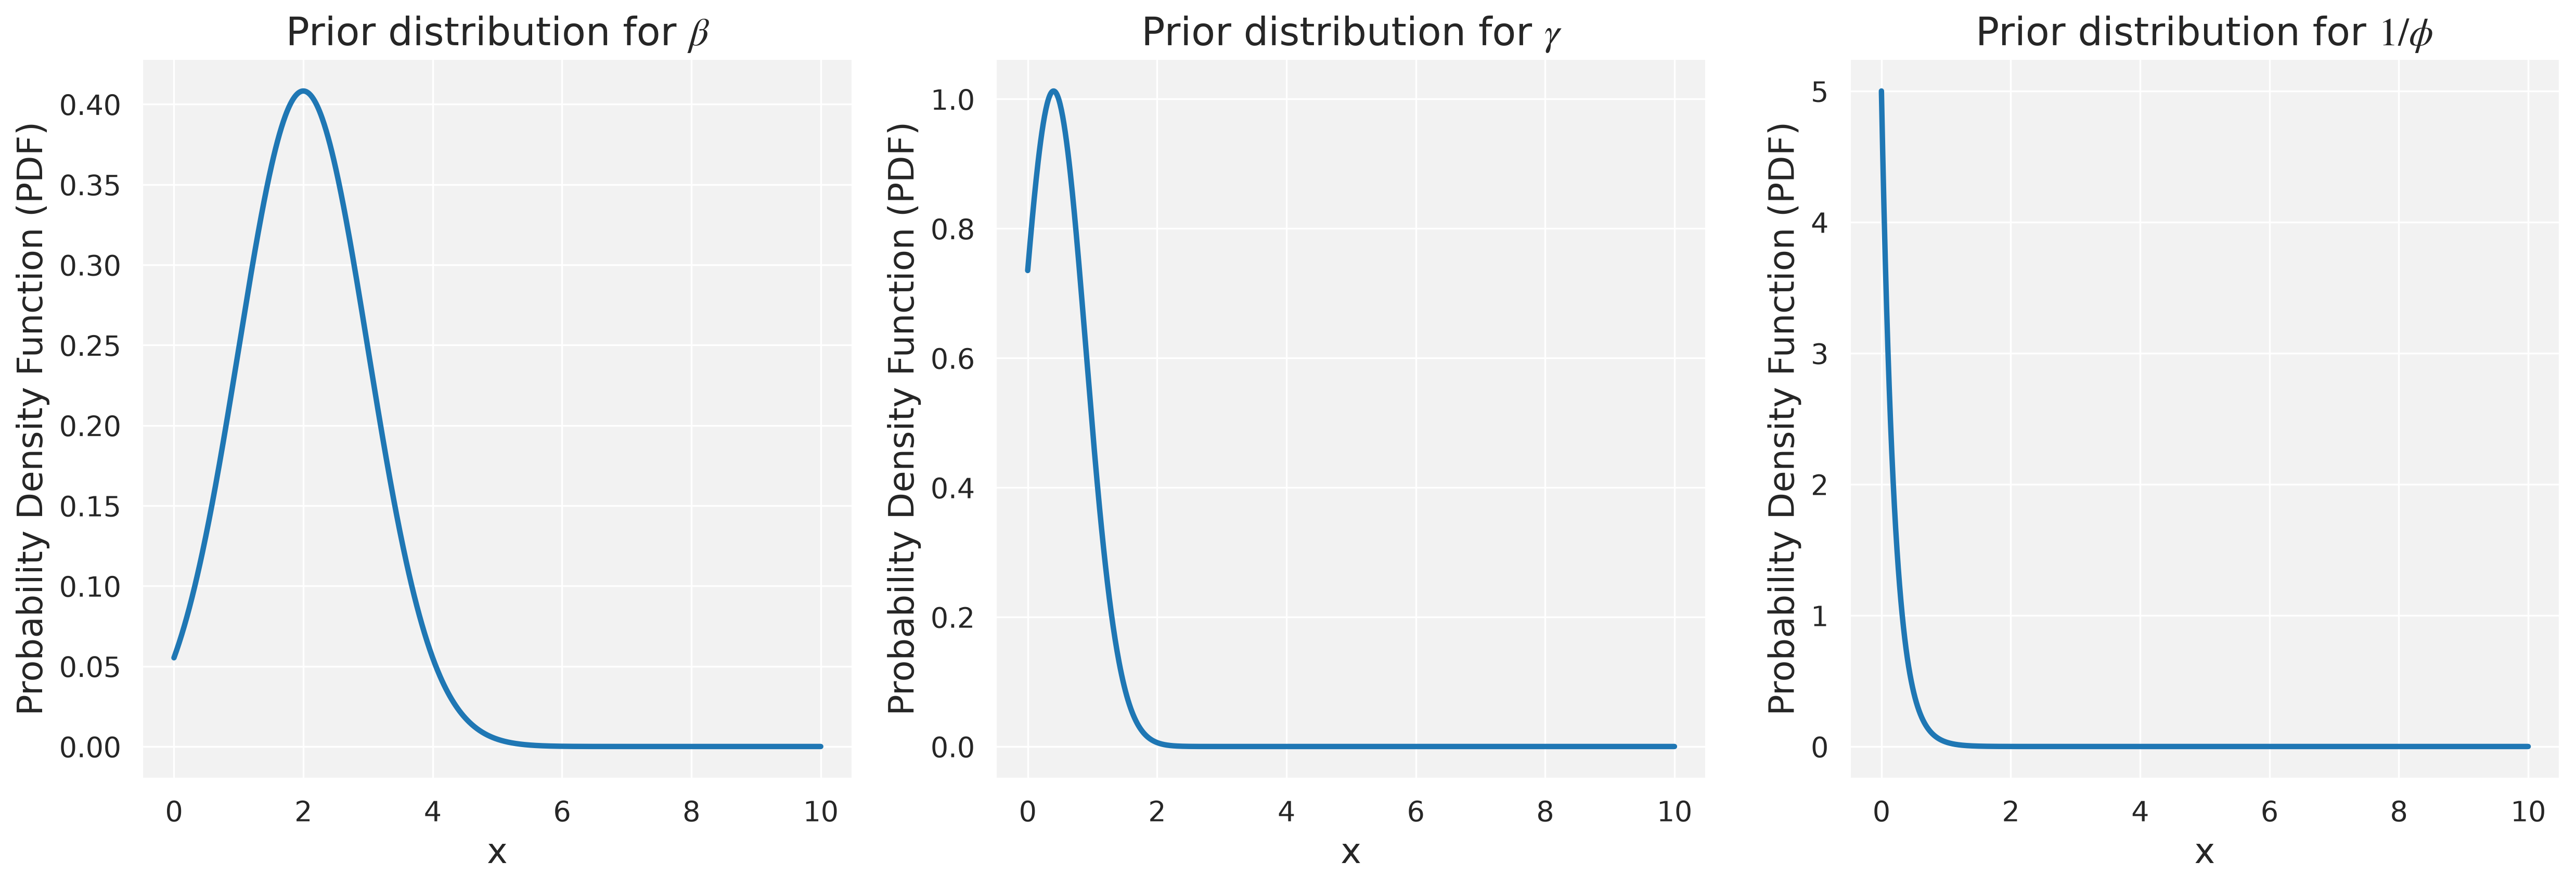

In [177]:
# prior distributions for beta, gamma and 1/phi
import scipy.stats as stats ## for statistical functions
import numpy as np ## for numerical computations


## beta prior distribution
plt.figure(figsize=(20, 6))

plt.subplot(1,3,1)
beta_mu, beta_sigma = 2,1

a,b = (0-beta_mu)/beta_sigma, np.inf ## normalization of mu and sigma for truncated normal distribution

dist = stats.truncnorm(a,b,loc=beta_mu,scale=beta_sigma) ## truncated normal distribution

x = np.linspace(0, 10, 1000) ## x values for plotting

sns.lineplot(x=x, y=dist.pdf(x)) ## plot the PDF of truncated normal distribution
plt.title(f"Prior distribution for $\\beta$")
plt.xlabel("x")
plt.ylabel("Probability Density Function (PDF)")

## gamma prior distribution
plt.subplot(1,3,2)
gamma_mu, gamma_sigma = 0.4,0.5

dist = stats.truncnorm((0-gamma_mu)/gamma_sigma, np.inf,loc=gamma_mu,scale=gamma_sigma) ## truncated normal distribution

sns.lineplot(x=x, y=dist.pdf(x)) ## plot the PDF of truncated normal distribution
plt.title(f"Prior distribution for $\\gamma$")
plt.xlabel("x")
plt.ylabel("Probability Density Function (PDF)")

## phi prior distribution
plt.subplot(1,3,3)
sns.lineplot(x=x, 
            y=stats.expon.pdf(x, scale=1/5)) ## plot the PDF of exponential distribution
plt.title(f"Prior distribution for $1/\\phi$")
plt.xlabel("x")
plt.ylabel("Probability Density Function (PDF)")

**Observations from the prior distributions**
1. For $\beta$, it is highly unlikely that the value is greater than 6.
2. For $\gamma$, entire mass of the distribution is confined between 0 and 2 with mean at 1. It will be a rare case that an infected child stays in bed for longer than 2 days.
3. For $1/\phi$, what?

**SIR model equations in Stan**

SIR model equations are ODEs representing change in values of $S(t),I(t),$ and $R(t)$ w.r.t. time, basically gradient of these values. In Stan for solving such ODEs, we need to define function of the form $y' = f(t,y, \mathcal{v}, x)$, where $y$ is the output or solution, $t$ is time,  $y'$ is derivative of $y$ w.r.t $t$, and $\mathcal{v}, x$ are the additional inputs required for solving an ODE. For example, in our illustration of SIR, $\mathcal{v}$ is the list of model parameters, which we want to infer and $x$ is the population size, which doesn't change with time.

In [6]:
## SIR model equations in Stan
sir_ode_function = """
functions {
  vector sir(
    real t,
    vector y,
    real beta,
    real gamma,
    real N
  ) {
    vector[3] dydt;

    dydt[1] = -beta * y[1] * y[2] / N;
    dydt[2] =  beta * y[1] * y[2] / N - gamma * y[2];
    dydt[3] =  gamma * y[2];

    return dydt;
  }
}
"""

**Syntax observations to note for coding in Stan:**
1. Need to define the variable data type, integer (int), real (real)
2. Need to define whether a variable is single number (nothing) or a list ([])
3. Semicolon after every complete line of code, no indentations needed
4. Two variables x_r, and x_i to have the flexibility of passing population size as either a real number or a integer. Kind of a downside while writing functions, but may be useful for backend C++ compiler.

**Defining the input data**


In [7]:
data = """
data {
  int<lower=1> n_days;
  vector[3] y0;
  real t0;
  array[n_days] real ts;
  real<lower=1> N;
  array[n_days] int<lower=0> cases;
}
"""

**Syntax observation to note**
1. value in square brackets after the variable name represents the length of that variable. In above snippet, y0[3] means y0 is of length 3, because it contains values in S, I, and R compartments. For 0 length variable, we write 0, as done for x_r[0].


**Defining the model parameters and ODE solver**

There are many solvers available in Stan to solve a system of ODEs, here we use Runge-Kutta method. We can obtain the solution of ODEs at any point in time with the given set of model parameters. In addition to that, we need to supply some extra initial values, which are the initial time $t0$, and initial value of the solution variable $y0$.

In [8]:
parameters = """
parameters{
real<lower = 0> beta;
real<lower = 0> gamma;
real<lower = 0> phi_inv;
}
"""


param_transform="""
transformed parameters {
  array[n_days] vector[3] y;
  real phi = 1.0 / phi_inv;

  y = ode_rk45(
    sir,
    y0,
    t0,
    ts,
    beta,
    gamma,
    N
  );
}
"""

**Syntax observation to note**
1. We need to provide the lower bounds for the model parameters, as we are using truncated normal distribution for $\beta$ and $\gamma$ parameters.
2. Note that phi is not a SIR model equation parameters thus not included in the theta list


**Defining model priors**


In [199]:
model = """
model {
beta ~ normal(2,1);
gamma ~ normal(0.4,0.5);
phi_inv ~ exponential(5);
}
"""

model_with_likeli = """
model {
beta ~ normal(2,1);
gamma ~ normal(0.4,0.5);
phi_inv ~ exponential(5);

for (d in 1:n_days) {
    cases[d] ~
      neg_binomial_2(y[d][2], phi);
  }
}


"""

gen_params = """
generated quantities {
  real R0 = beta / gamma;
  real recovery_time = 1.0 / gamma;
  array[n_days] int pred_cases;

  for (d in 1:n_days) {
    pred_cases[d] =
      neg_binomial_2_rng(y[d][2] + 1e-5, phi);
  }
}
"""

**Data preparation to feed to stan**

In [254]:
N = 763
t0 = 0

cases = df.in_bed.values
n_days = df.shape[0]
t = np.arange(1, n_days+1, 1) ## every value should be strictly greater than t0


i0 = 1
s0 = N - i0
r0 = 0
y0 = [s0,i0,r0]

## match the data type defined in the stan data code
data_sir = {
    "n_days": int(n_days),
    "y0": np.asarray(y0, dtype=float).reshape(3),
    "t0": float(t0),
    "ts": np.asarray(t, dtype=float).reshape(-1),
    "N": float(N),
    "cases": np.asarray(cases, dtype=int).reshape(-1),
}


## Validating priors

In [215]:
posterior_without_likelihood = stan.build(sir_ode_function + data  + parameters + param_transform + model + gen_params,
                                data = data_sir,
                                )

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_6ioyz_vn/model_6ibz7c5j.stan', line 39, column 6: The
    variable sir may not have been assigned a value before its use.


In [216]:
sir_fit_without_likelihood = posterior_without_likelihood.sample(num_chains=4)

Sampling:   0%Future exception was never retrieved
future: <Future finished exception=RuntimeError('write: Broken pipe [system:32]')>
concurrent.futures.process._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/home/neha/miniconda3/envs/stan_bayes/lib/python3.11/concurrent/futures/process.py", line 261, in _process_worker
    r = call_item.fn(*call_item.args, **call_item.kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/neha/miniconda3/envs/stan_bayes/lib/python3.11/site-packages/httpstan/services_stub.py", line 47, in _make_lazy_function_wrapper_helper
    return function(*args, **kwargs)  # type: ignore
           ^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: write: Broken pipe [system:32]
"""

The above exception was the direct cause of the following exception:

RuntimeError: write: Broken pipe [system:32]

Sampling:   0% (1/8000)
Sampling:   1% (101/8000)
Sampling:   3% (201/8000)
Sampling:   4% (301/8000)
Sampling:   9% (701/8000)
Sampling:

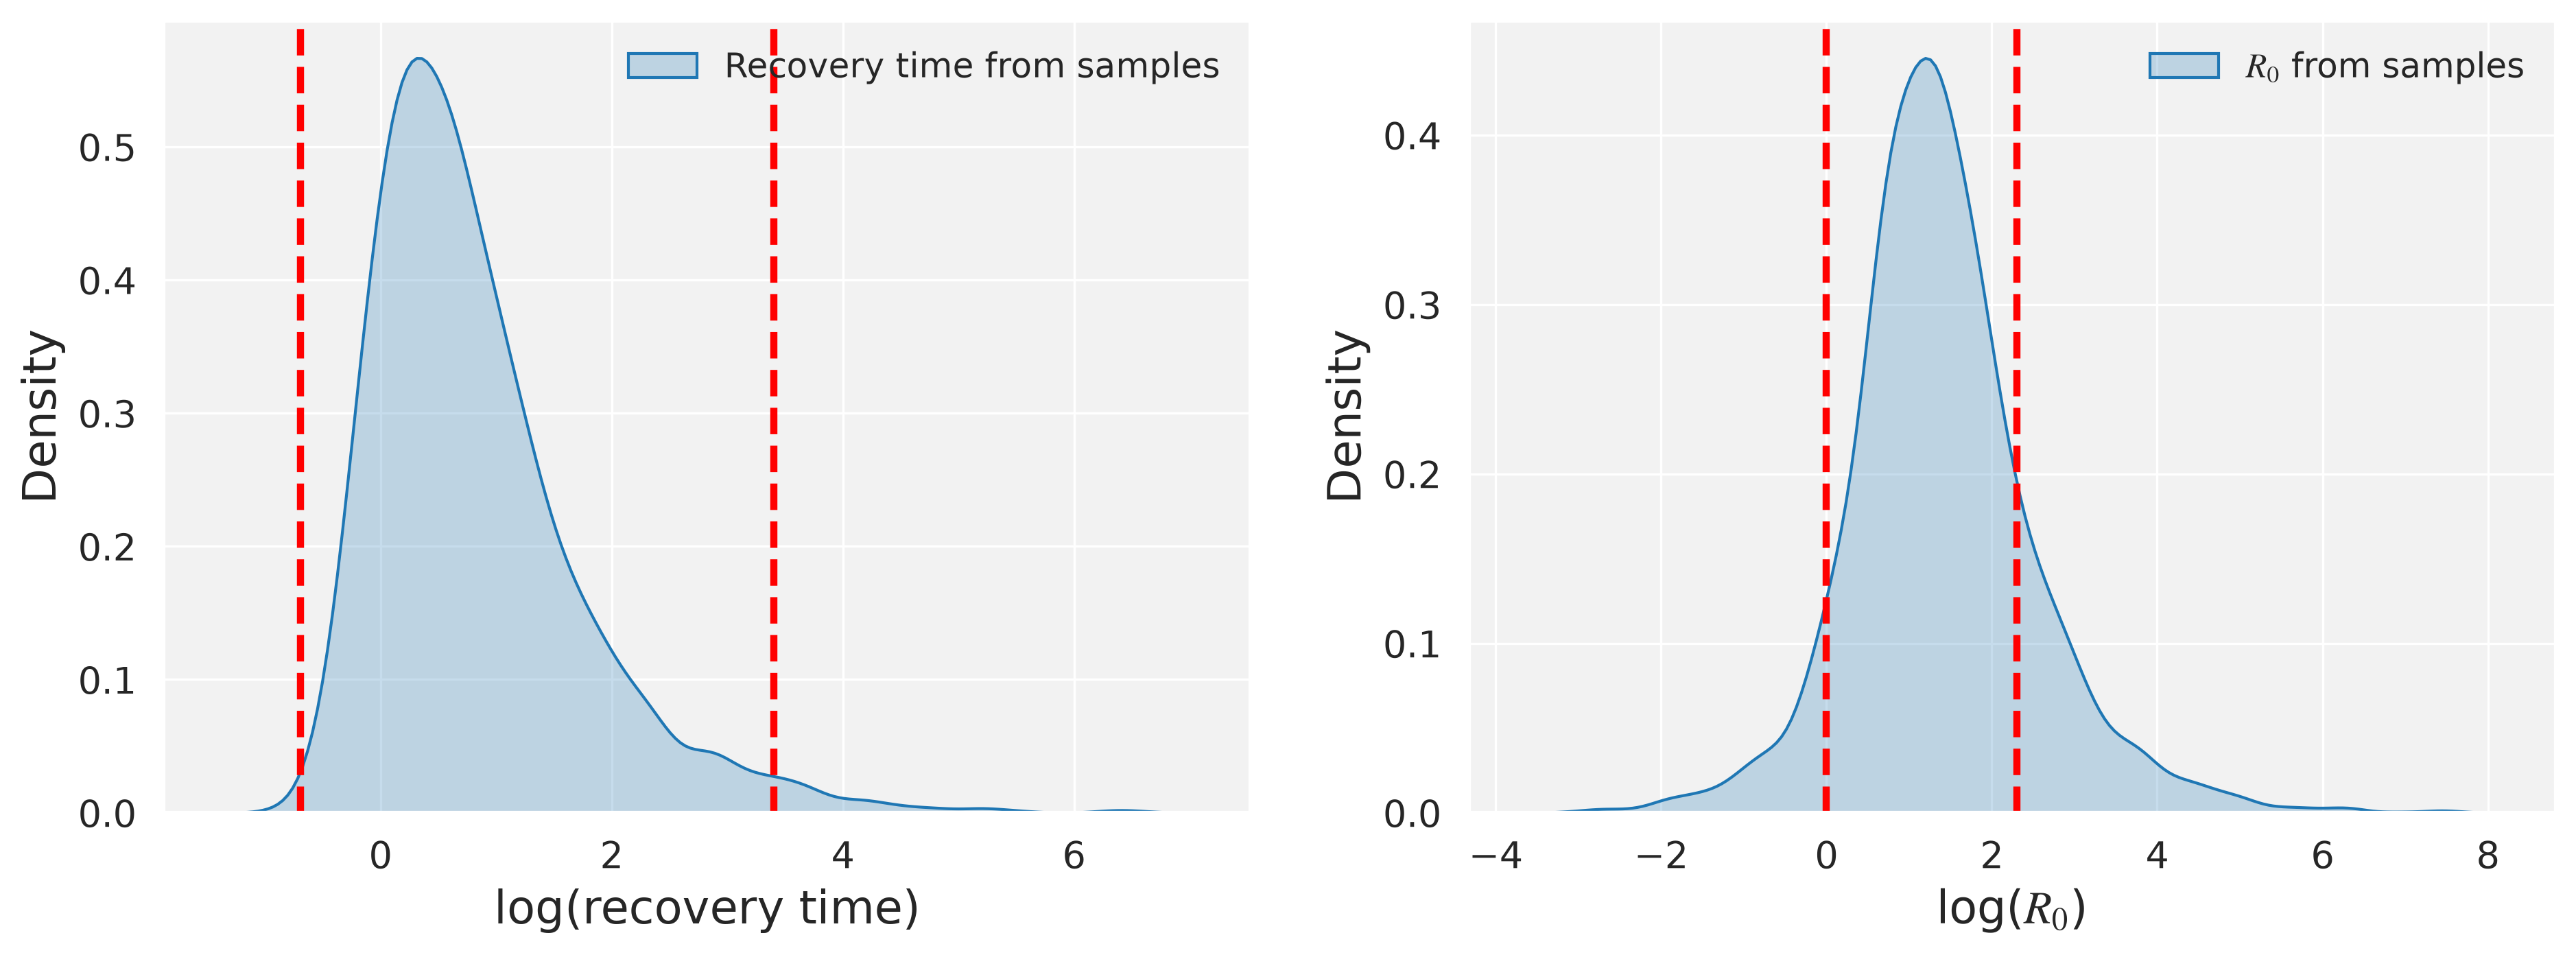

In [252]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.kdeplot(np.log(sir_fit_without_likelihood['recovery_time'][0,:]), label="Recovery time from samples", fill=True)
plt.axvline(x=np.log(0.5), color='red', linestyle='--')
plt.axvline(x=np.log(30), color='red', linestyle='--')
plt.xlabel(f"log(recovery time)")
plt.legend()
plt.subplot(1,2,2)
sns.kdeplot(np.log(sir_fit_without_likelihood['R0'][0,:]), label=f"$R_0$ from samples", fill=True)
plt.axvline(x=np.log(1), color='red', linestyle='--')
plt.axvline(x=np.log(10), color='red', linestyle='--')
plt.xlabel(f"log($R_0$)")
plt.legend()

Text(0, 0.5, 'Children in bed (infected)')

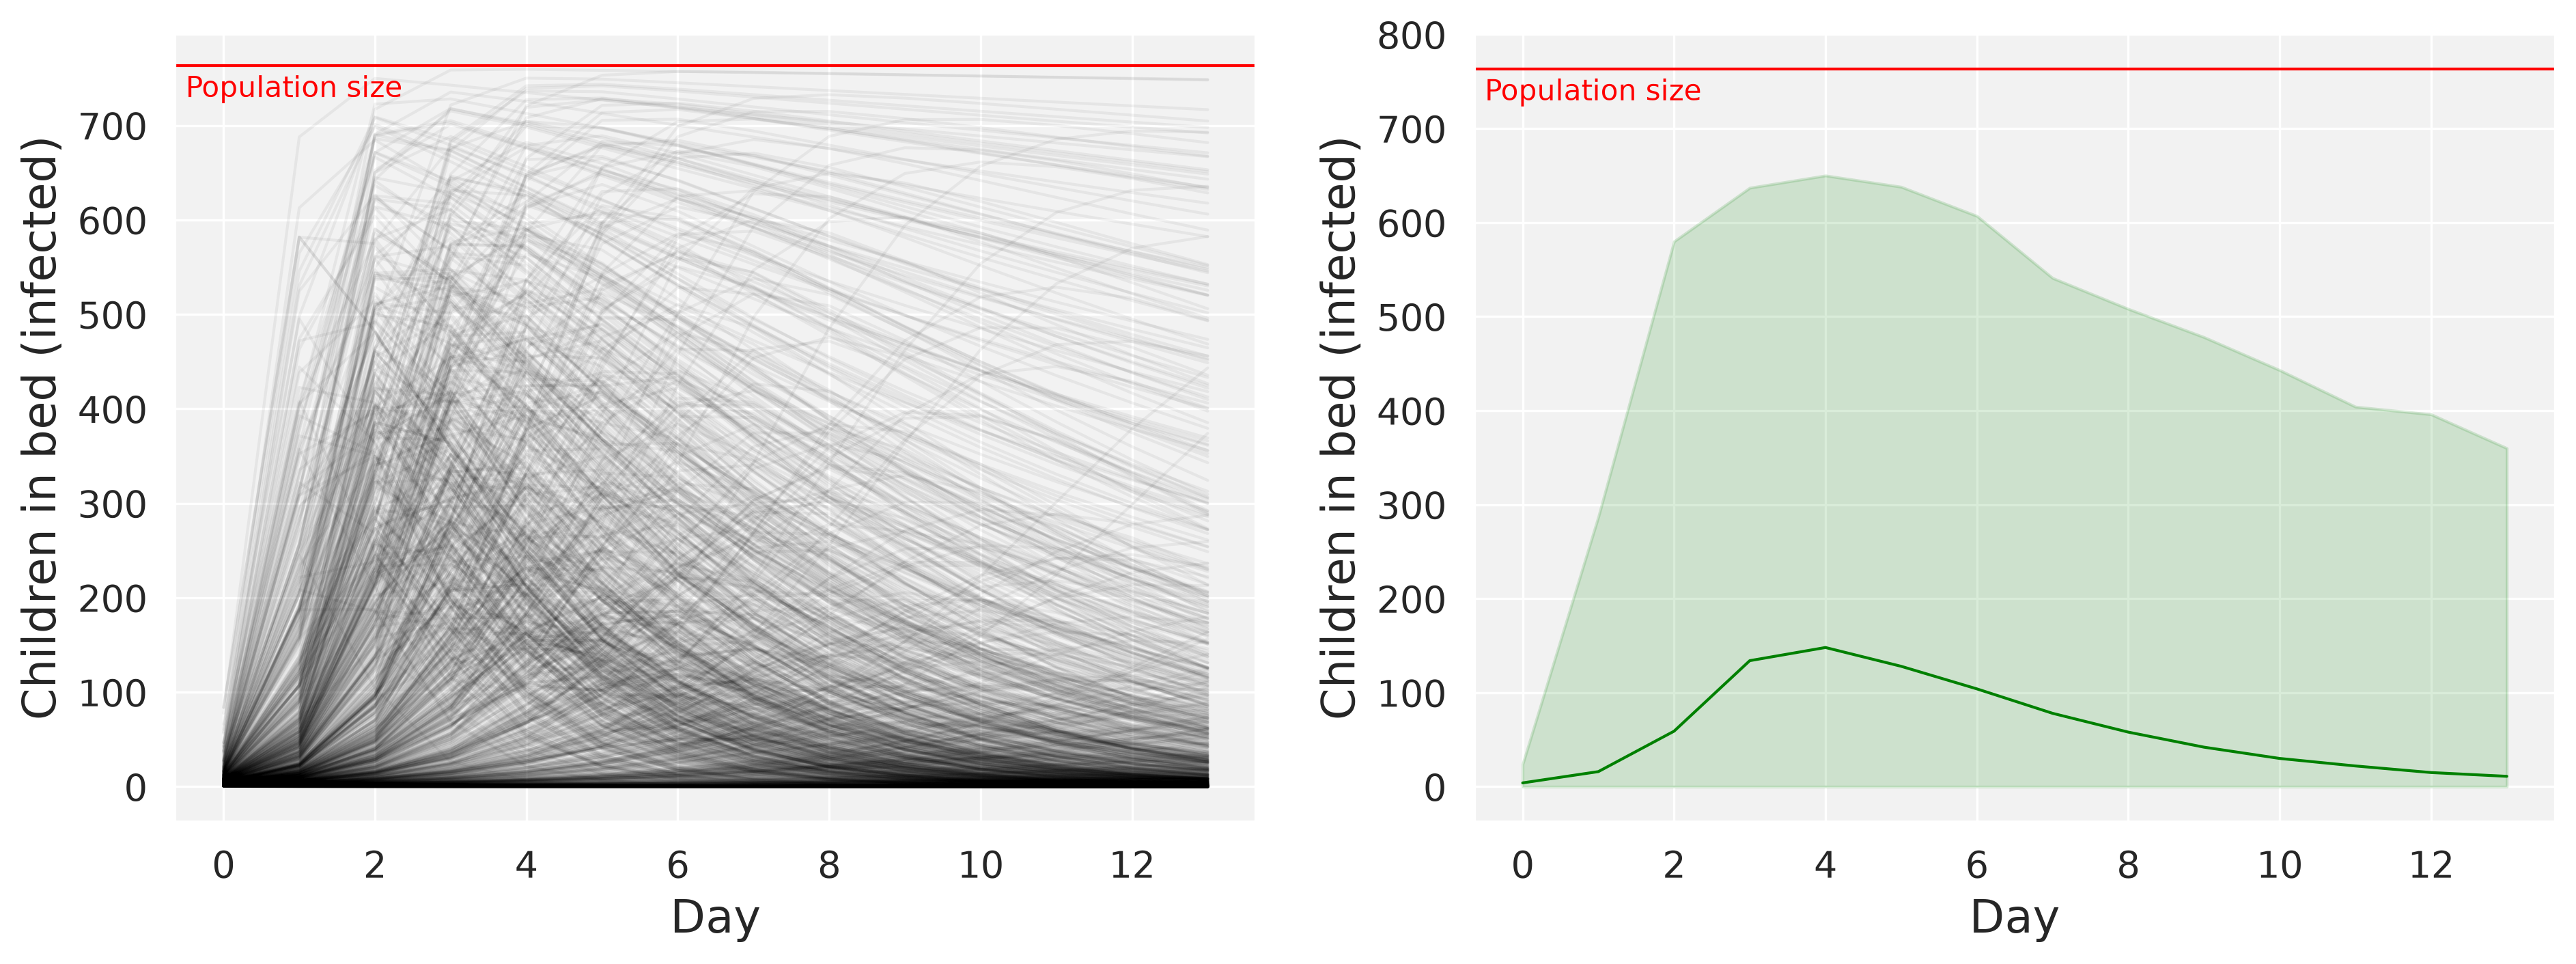

In [218]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
for i in range(1000):
    plt.plot(sir_fit_without_likelihood['y'][:,1,i], color='black',linewidth=1, alpha=0.05)
plt.axhline(y=N, color='red',lw=1)
plt.text(x=-0.5,y=730,s="Population size",color='red',fontsize=10)
plt.xlabel("Day")
plt.ylabel("Children in bed (infected)")

plt.subplot(1,2,2)
summary_df = pd.DataFrame(sir_fit_without_likelihood["pred_cases"].T).describe(percentiles=[0.05,0.5,0.95]).T
plt.plot(summary_df['50%'].values,color='green',lw=1)
plt.fill_between(x=np.arange(0,14,1),
                y1= summary_df['5%'].values,
                y2= summary_df['95%'].values,
                color='green', alpha=0.15
                 )
plt.axhline(y=N, color='red',lw=1)
plt.text(x=-0.5,y=730,s="Population size",color='red',fontsize=10)
plt.xlabel("Day")
plt.ylabel("Children in bed (infected)")

## Validating model set - obtaining priors

In [219]:
sim_data = sir_fit_without_likelihood["pred_cases"][:,10]
sim_data_sir = {
    "n_days": int(n_days),
    "y0": np.asarray(y0, dtype=float).reshape(3),
    "t0": float(t0),
    "ts": np.asarray(t, dtype=float).reshape(-1),
    "N": float(N),
    "cases": np.asarray(sim_data, dtype=int).reshape(-1)
}


In [220]:
posterior_with_likelihood_sim_data = stan.build(sir_ode_function + data  + parameters + param_transform + model_with_likeli + gen_params,
                                        data = sim_data_sir,
                                        )

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_bq4xoufx/model_kyemayr2.stan', line 39, column 6: The
    variable sir may not have been assigned a value before its use.


In [221]:
sir_fit_with_likelihood_sim_data = posterior_with_likelihood_sim_data.sample(num_chains=4)

Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   0% (2/8000)
Sampling:   5% (401/8000)
Sampling:  10% (800/8000)
Sampling:  15% (1200/8000)
Sampling:  35% (2800/8000)
Sampling:  50% (4000/8000)
Sampling:  50% (4001/8000)
Sampling:  51% (4100/8000)
Sampling:  52% (4200/8000)
Sampling:  54% (4300/8000)
Sampling:  55% (4400/8000)
Sampling:  58% (4600/8000)
Sampling:  59% (4700/8000)
Sampling:  60% (4800/8000)
Sampling:  75% (6000/8000)
Sampling:  86% (6900/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 0.00041 seconds
  1000 transitions using 10 leapfrog steps per transition would take 4.1 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: neg_binomial_2_lpmf: Precision parameter is 0, but must be positive finite! (in '/tmp/httpstan_8s08yo6q/model_kyemayr2.stan', line 56, column 4 to 

In [235]:
print(f"True parameter values: \nbeta:{sir_fit_without_likelihood['beta'][:,10]} \ngamma:{sir_fit_without_likelihood['gamma'][:,10]} \nphi:{sir_fit_without_likelihood['phi'][:,10]}")

True parameter values: 
beta:[1.79370371] 
gamma:[0.19375092] 
phi:[4.92736806]


In [243]:
param_df = pd.DataFrame([sir_fit_with_likelihood_sim_data['beta'][0,:],
                sir_fit_with_likelihood_sim_data['gamma'][0,:],
                sir_fit_with_likelihood_sim_data['phi'][0,:],
              ]).T
param_df.columns = ['beta','gamma','phi']
param_df.describe()

,beta,gamma,phi
count,4000.000000,4000.000000,4000.000000
mean,1.674636,0.189461,5.857055
std,0.107216,0.028076,2.432207
min,1.374804,0.046372,1.309042
25%,1.601783,0.173619,4.102508
50%,1.664900,0.190817,5.391972
75%,1.733747,0.207183,7.141558
max,2.343804,0.305782,18.537371


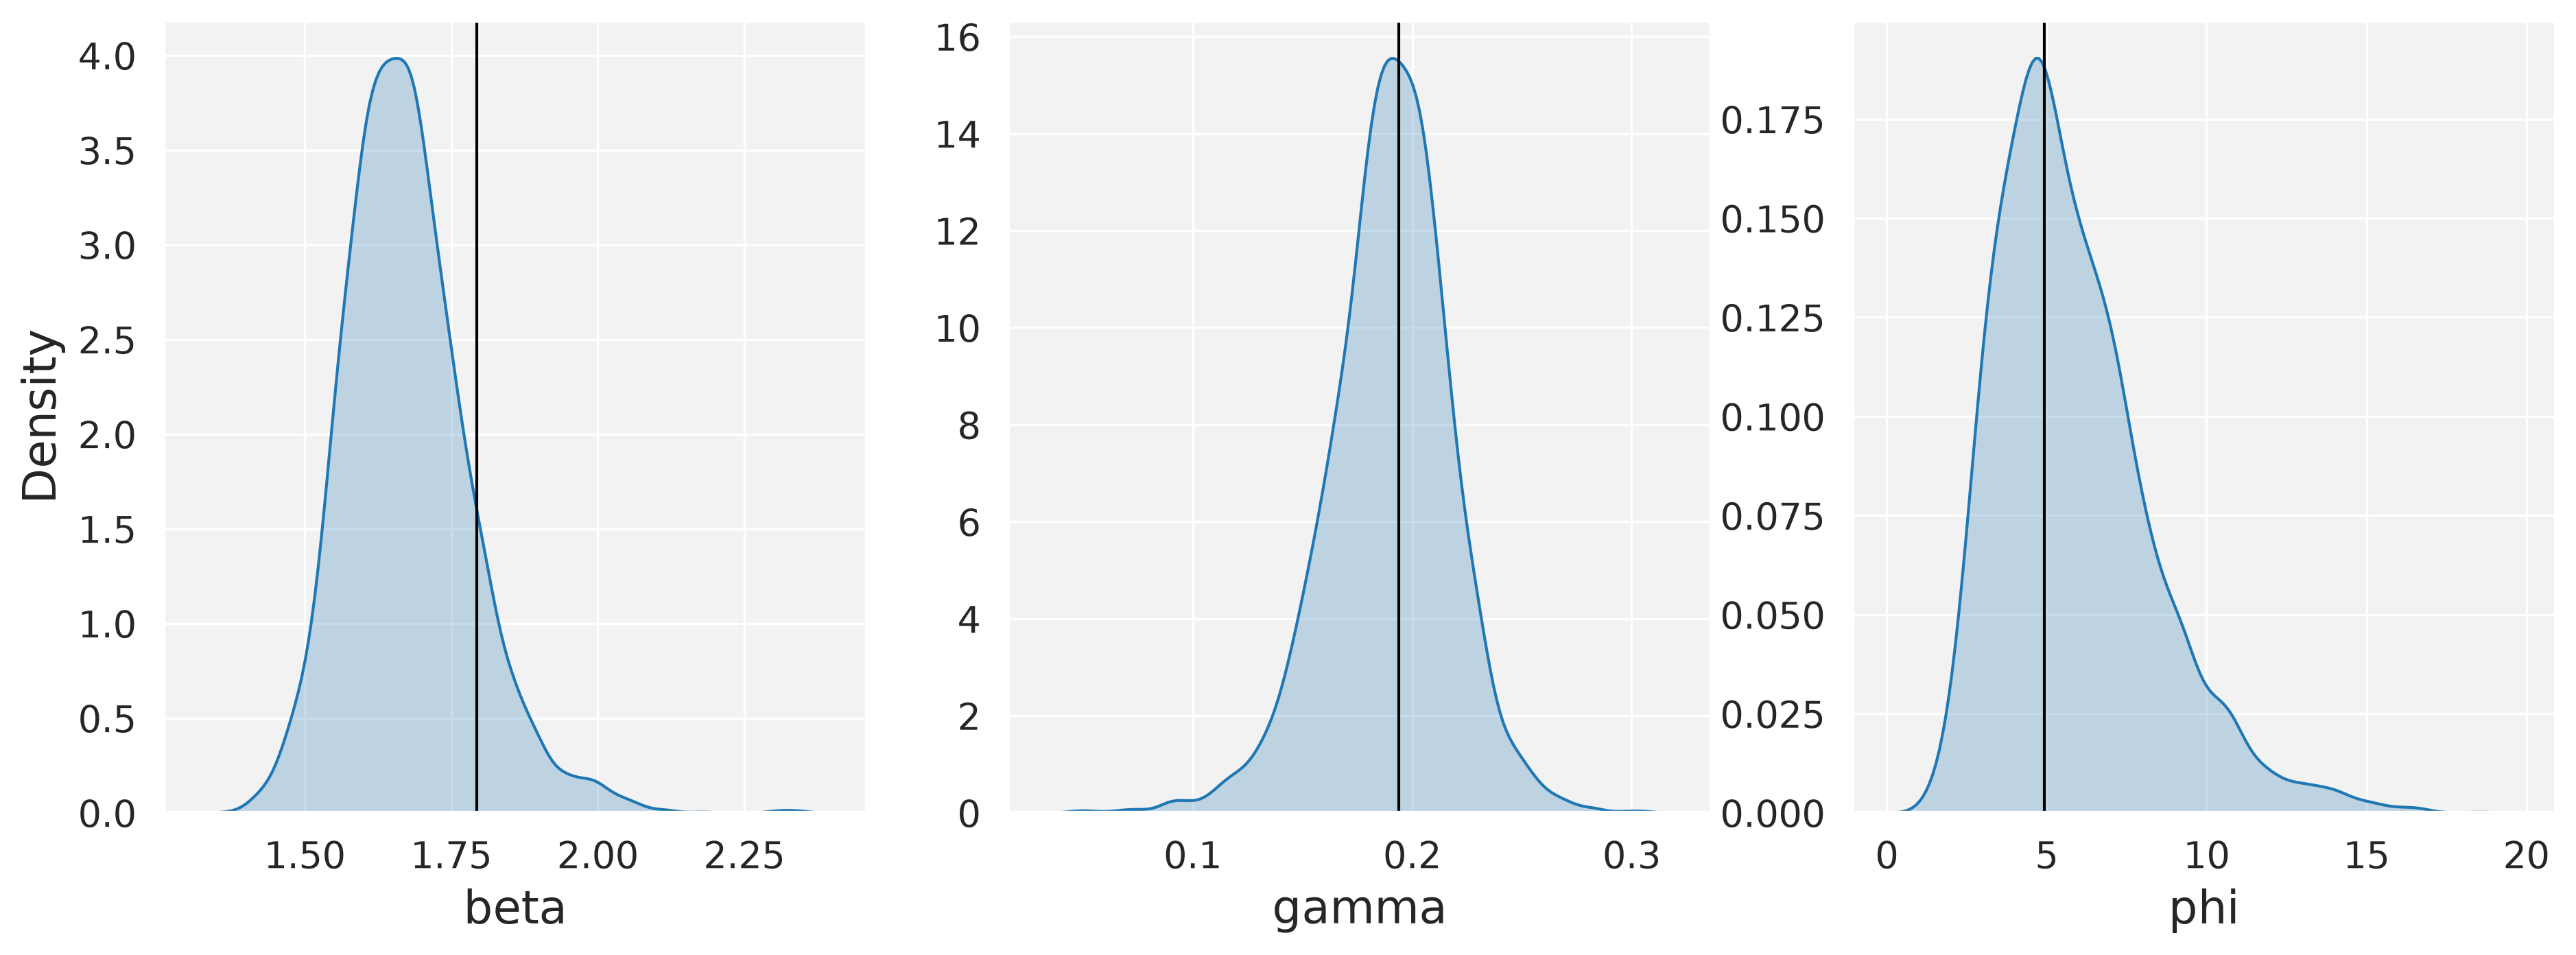

In [250]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.kdeplot(param_df['beta'], fill=True)
plt.axvline(x=sir_fit_without_likelihood['beta'][:,10],color='black',lw=1)
plt.subplot(1,3,2)
sns.kdeplot(param_df['gamma'], fill=True)
plt.ylabel("")
plt.axvline(x=sir_fit_without_likelihood['gamma'][:,10],color='black',lw=1)
plt.subplot(1,3,3)
sns.kdeplot(param_df['phi'], fill=True)
plt.ylabel("")
plt.axvline(x=sir_fit_without_likelihood['phi'][:,10],color='black',lw=1)


## Using real data

In [257]:
posterior_with_likelihood_real_data = stan.build(sir_ode_function + data  + parameters + param_transform + model_with_likeli + gen_params,
                                        data = data_sir,
                                        )

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_bq4xoufx/model_kyemayr2.stan', line 39, column 6: The
    variable sir may not have been assigned a value before its use.


In [260]:
sir_fit_with_likelihood_real_data = posterior_with_likelihood_real_data.sample(num_chains=4, )

Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   0% (2/8000)
Sampling:   5% (401/8000)
Sampling:   8% (600/8000)
Sampling:  12% (1000/8000)
Sampling:  28% (2200/8000)
Sampling:  28% (2201/8000)
Sampling:  28% (2202/8000)
Sampling:  29% (2301/8000)
Sampling:  30% (2400/8000)
Sampling:  31% (2500/8000)
Sampling:  35% (2800/8000)
Sampling:  39% (3100/8000)
Sampling:  42% (3400/8000)
Sampling:  46% (3700/8000)
Sampling:  62% (5000/8000)
Sampling:  78% (6200/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 0.000413 seconds
  1000 transitions using 10 leapfrog steps per transition would take 4.13 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: neg_binomial_2_lpmf: Location parameter is -2.77969e-07, but must be positive finite! (in '/tmp/httpstan_8s08yo6q/model_kyemayr2.stan', line 56, 

In [275]:
param_df = pd.DataFrame({'beta':sir_fit_with_likelihood_real_data['beta'][0,:],
                'gamma':sir_fit_with_likelihood_real_data['gamma'][0,:],
                'phi':sir_fit_with_likelihood_real_data['phi'][0,:],
                'recovery_time':sir_fit_with_likelihood_real_data['recovery_time'][0,:],
                'R0':sir_fit_with_likelihood_real_data['R0'][0,:],
              })
param_df.describe()

,beta,gamma,phi,recovery_time,R0
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1.735440,0.542195,9.470232,1.857234,3.221816
std,0.052530,0.045098,5.256086,0.156353,0.274683
min,1.531146,0.349487,1.544114,1.330938,2.357538
25%,1.702257,0.513329,5.874370,1.752928,3.041237
50%,1.733675,0.539919,8.327291,1.852129,3.204409
75%,1.768185,0.570474,11.805658,1.948069,3.371964
max,2.167512,0.751350,53.299337,2.861340,5.073566


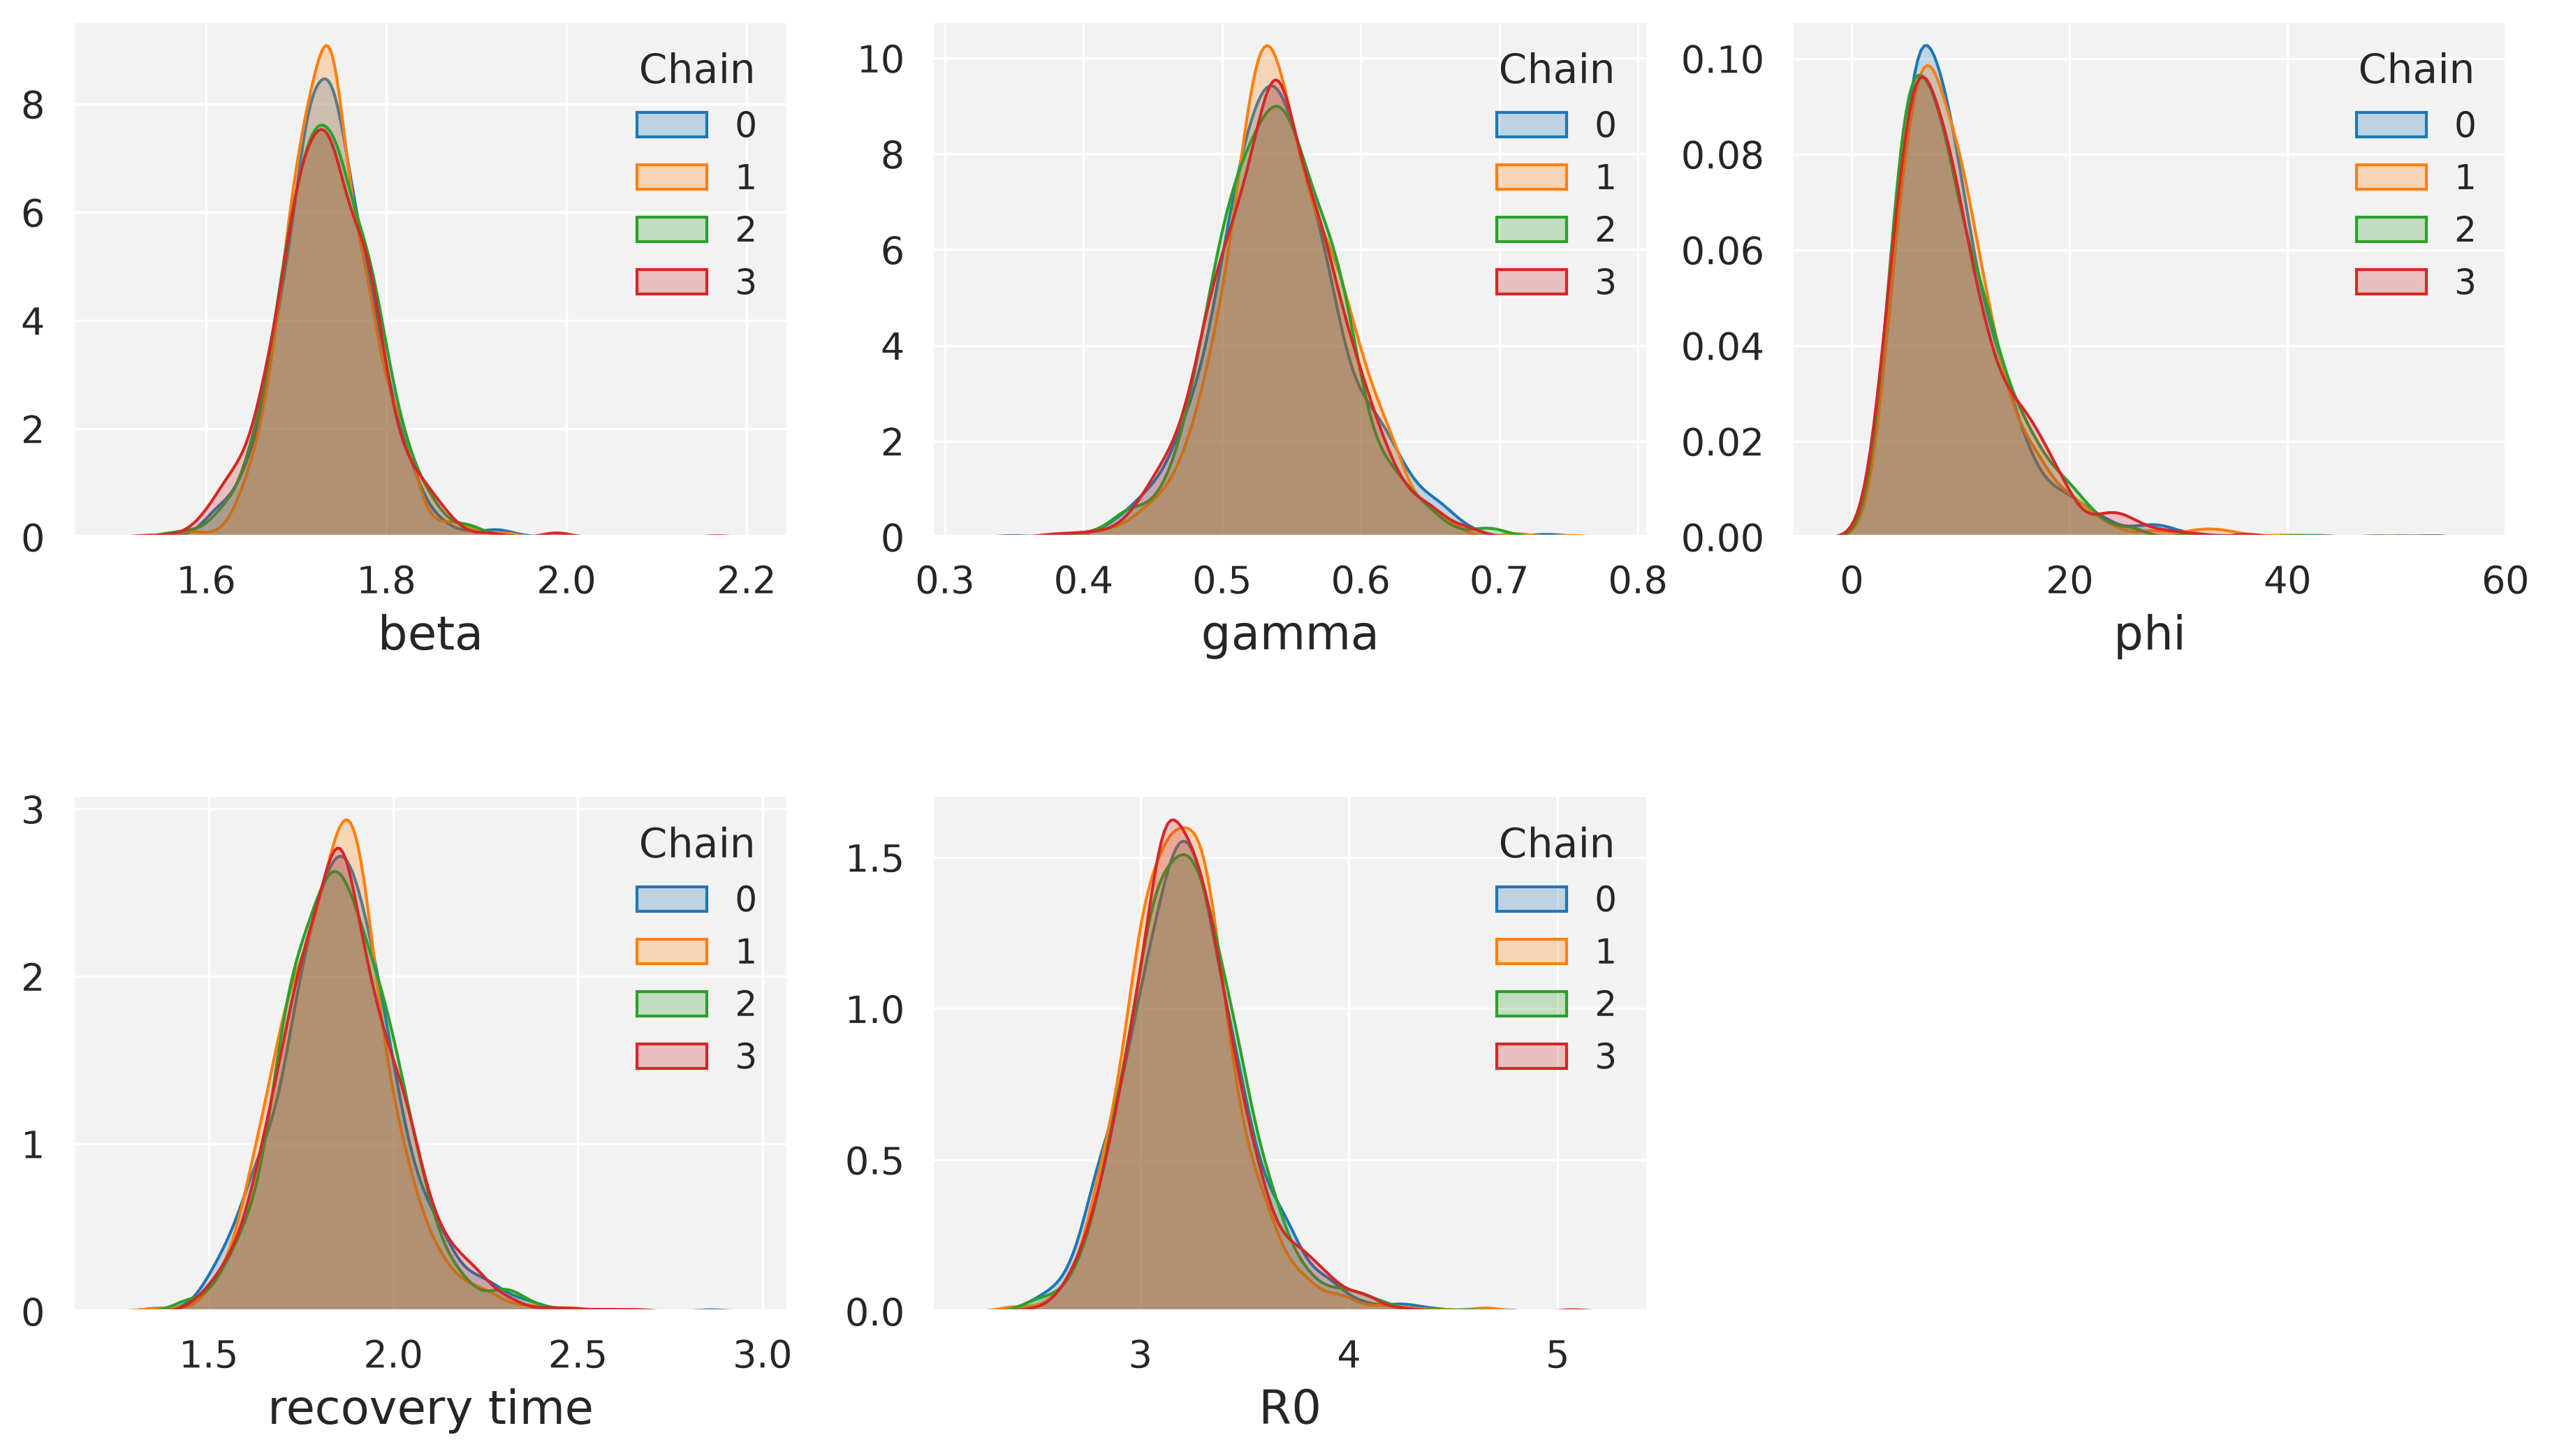

In [282]:
plt.figure(figsize=(15,8))
plt.subplots_adjust(hspace=0.5)
plt_cnt = 1
for param in param_df.columns:
    plt.subplot(2,3,plt_cnt)
    reshaped_beta = sir_fit_with_likelihood_real_data[param].reshape(4,1000)
    for i in range(4):
        sns.kdeplot(reshaped_beta[i,:],fill=True,label=i)
    plt.xlabel(param.replace("_"," "))
    plt.ylabel("")
    plt.legend(title="Chain")
    plt_cnt+=1

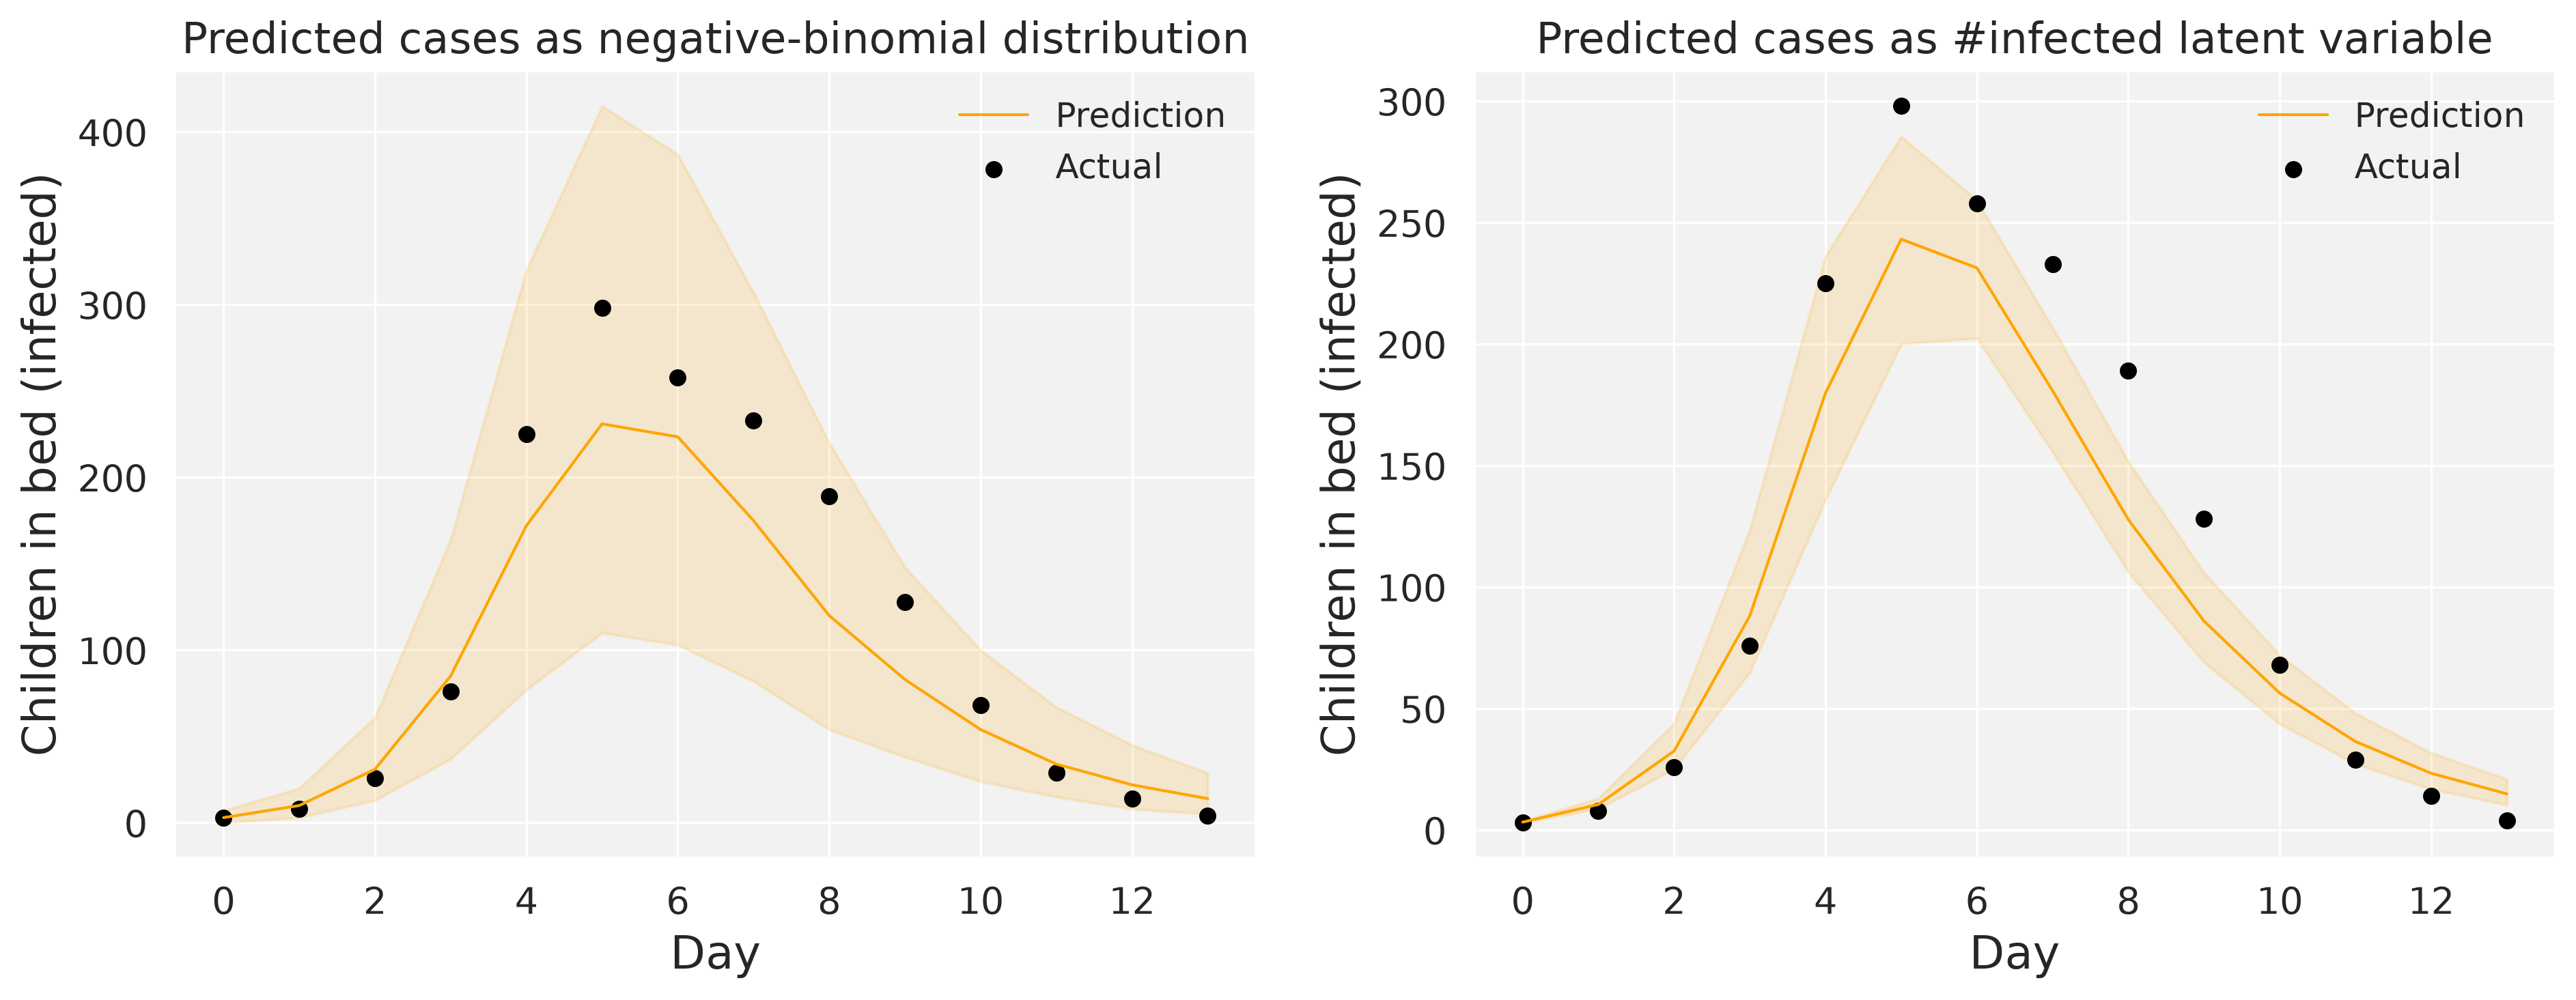

In [300]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
summary_df = pd.DataFrame(sir_fit_with_likelihood_real_data["pred_cases"].T).describe(percentiles=[0.05,0.5,0.95]).T
plt.plot(summary_df['50%'].values,color='orange',lw=1,label="Prediction")
plt.fill_between(x=np.arange(0,14,1),
                y1= summary_df['5%'].values,
                y2= summary_df['95%'].values,
                color='orange', alpha=0.15
                 )
plt.scatter(x=np.arange(0,14,1),y=data_sir['cases'],color='black',s=25,label='Actual')
plt.xlabel("Day")
plt.ylabel("Children in bed (infected)")
plt.title("Predicted cases as negative-binomial distribution",fontsize=15)
plt.legend()
plt.subplot(1,2,2)

summary_df = pd.DataFrame(sir_fit_with_likelihood_real_data["y"][:,1,:].T).describe(percentiles=[0.05,0.5,0.95]).T
plt.plot(summary_df['50%'].values,color='orange',lw=1,label="Prediction")
plt.fill_between(x=np.arange(0,14,1),
                y1= summary_df['5%'].values,
                y2= summary_df['95%'].values,
                color='orange', alpha=0.15
                 )
plt.scatter(x=np.arange(0,14,1),y=data_sir['cases'],color='black',s=25,label="Actual")
plt.xlabel("Day")
plt.ylabel("Children in bed (infected)")
plt.title("Predicted cases as #infected latent variable",fontsize=15)
plt.legend()